# 노드 4. 인물사진을 만들어 보자 [프로젝트]

## 1. 인물 모드 문제점 찾기

우선 주요 라이브러리 버전을 확인

In [1]:
!pip install opencv-python pixellib

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 53.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 115.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 53.3 MB/s eta 0:00:00:00:0100:01
  DEPRECATION: Building 'fvcore' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517`

In [2]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.11.0


## Step 1. 인물모드 직접 해 보기

- 여러분의 셀카를 이용해서 오늘 배운 내용을 수행해 봅시다. 아래와 같은 이미지를 얻어야 합니다. 최소 3장 이상의 인물모드 사진을 만들어 봅시다.
- 인물이 주인공이 아닌, 귀여운 고양이에 대한 아웃포커싱 사진도 만들어 볼 수 있을 것입니다. 시맨틱 세그멘테이션 스텝에서 힌트를 찾아봅시다.
- 배경을 blur하는 인물모드 사진이 아니라 배경사진을 다른 이미지로 교체하는 크로마키 배경 합성을 시도해 볼 수도 있을 것입니다. 여러분만의 환상적인 사진을 만들어 보면 어떨까요?

원본 고양이 이미지 크기: (512, 768, 3)
배경(사막) 이미지 크기: (512, 910, 3)


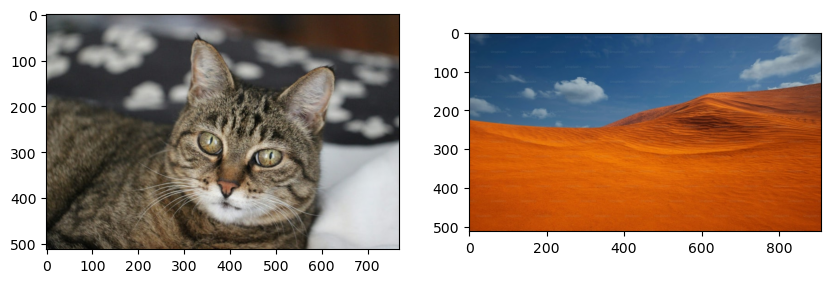

In [3]:
cat_img_path = "cat.jpg"  # 고양이 이미지를 준비해주세요
sand_img_path = "sand.jpg"  # 사막 배경 이미지를 준비해주세요

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [4]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /home/jovyan/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:02<00:00, 101MB/s]  


추론 마스크 크기 (Before Resize): (520, 520)


In [5]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (512, 768)


In [6]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


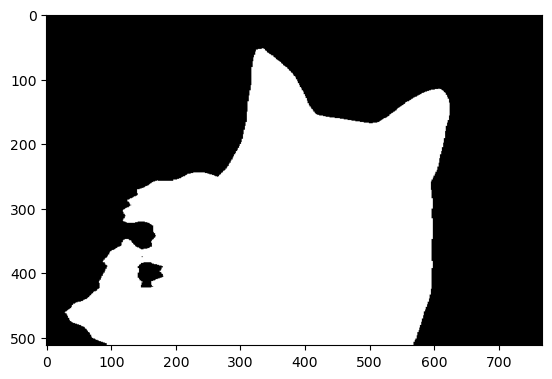

In [7]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

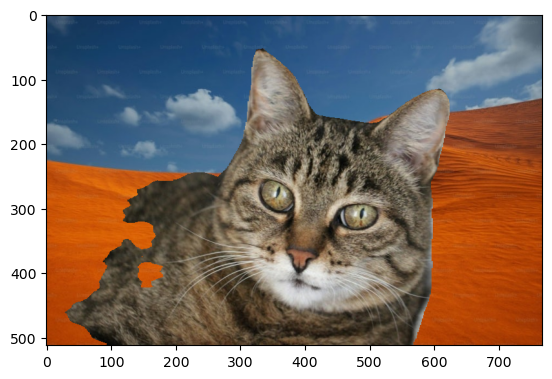

In [8]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

## Step 2. 사진에서 문제점 찾기
그러나 여러분들의 사진에는 무언가 문제점이 있을 것입니다.

여러분이 만들어 낸 인물 모드 사진 중 하나에서도 이상한 위치를 찾아 아래 사진처럼 표시해 봅시다. 표시한 이미지들을 jupyter notebook에 포함하여 제출해 주세요.

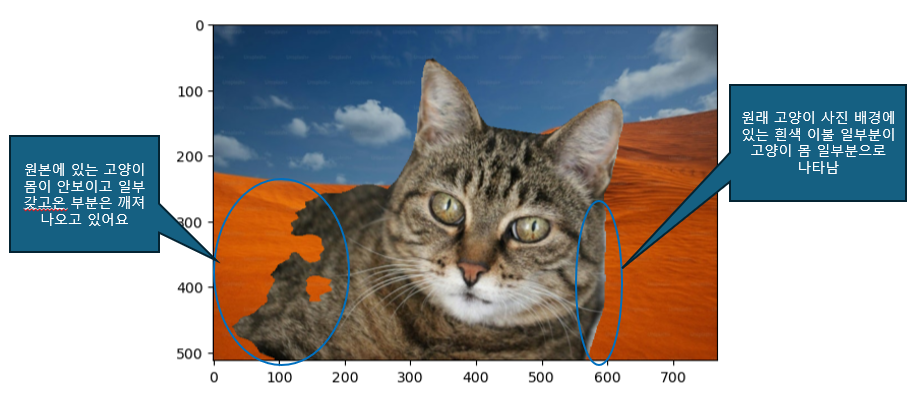

### 제일 밑에서 진행한 고양이 사진에도 문제점 발견

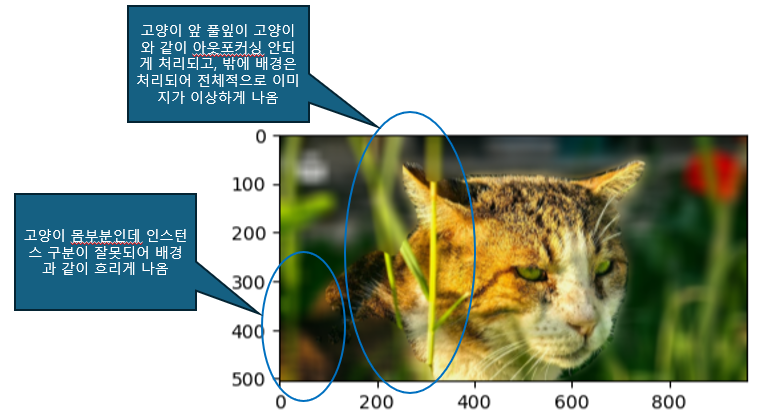

## Step 3. 해결 방법을 제안해 보기

아주 간단히 멋진 카메라 앱 서비스를 만들어 출시할 수 있을 것 같았지만, 지금 같은 완성도로는 어림도 없습니다. 소비자들의 눈높이는 그리 호락호락하지 않고, 엔지니어인 여러분들은 답을 찾아내야 합니다.

생각해 볼 만한 주제를 아래에 몇 가지 제시해 봅니다. 아래를 읽어본 후, 여러분이 만든 인물모드 사진의 문제점을 해결할 방안을 정리하여 제안해 주시기 바랍니다.
단순히 'XXX 기술을 사용한다.' 정도의 선언적 솔루션이 아니라, 여러분들이 선택한 기술이 DeepLab 모델의 Semantic Segmentation 이 만들어 낸 Mask 영역에 어떻게 적용되어 문제점을 보완하게 되는지의 메커니즘이 포함된 솔루션이어야 합니다.

### 세그멘테이션의 한계
Semantic segmentation의 부정확성이 여러 가지 문제를 발생시키는 주요 원인입니다. 피사계심도를 이용한 보케(아웃포커싱) 효과는 말 그대로 심도를 표현하기 때문에 초점이 잡힌 거리를 광학적으로 아주 섬세하게 구별(segmentation) 하지만 이를 따라 한 semantic segmentation 모듈은 정확도가 1.00 이 되지 않는 한 완벽히 구현하기는 힘듭니다.

### 피사계 심도 이해하기
우선 피사계심도의 개념부터 명확히 이해해 봅시다.

- [아웃포커싱 하는 법](https://m.blog.naver.com/typs6301/222172333739)
- [얕은 피사계 심도 촬영의 이해](https://www.adobe.com/kr/creativecloud/photography/discover/shallow-depth-of-field.html)

### 3D Camera 활용하기
이미지를 2D 방식으로 받아들이는 한계를 넘어 3D로 인식하려는 시도는 꽤 오래전부터 계속되어 왔습니다. 기술도 이제는 상당한 수준에 이르렀는데요. 크게는 스테레오 비전, ToF 방식 등이 자주 사용됩니다. 하드웨어 이미지 센서를 통한 3D 이미징 기술이 많이 발전되었는데요. 아래 참고 자료를 통해 최신 기술을 살펴봐도 좋습니다.

- [3D 이미지센서](https://news.skhynix.co.kr/next-gen-3d/)
  
### 소프트웨어 기술 활용하기
하드웨어 개발과 생산에는 비용이 많이 들기 때문에 제한된 하드웨어를 이용하면서 소프트웨어로 그 한계를 극복하려는 노력도 많습니다. 구글의 struct2Depth가 대표적인 예일 것 같습니다.

- [Unsupervised Learning of Depth and Ego-Motion: A Structured Approach
15-2](https://sites.google.com/view/struct2depth)

딥러닝이 발전한 지금은 더 다양한 기술이 개발되어 있으니 잘 탐색해 보세요.

### 다른 기술과 융합해 보기

구글 pixel4에는 IR(적외선) 카메라가 달려있는데요. 물체의 온도를 측정하는 IR 카메라와 3D 이미지는 크게 관련이 없을 것 같지만, 이를 통해 보다 멋진 3d depth sensing이 가능하다는군요.

- [uDepth: Real-time 3D Depth Sensing on the Pixel 4](https://research.google/blog/udepth-real-time-3d-depth-sensing-on-the-pixel-4/)

이렇게 카메라와 무관한 다른 기술과 융합하는 것도 좋은 해결책이 될 수 있습니다. 한 번 고민해 보세요!

이 외에도 다른 방식으로 접근해도 좋습니다. 엔지니어로서 본인이 선택한 솔루션을 잘 설명해 주세요. 가능하다면 순서도(Flow Chart)를 활용하면 좋습니다. 멋진 아이디어를 기대하겠습니다!!

## 해결 방법 제안

DeepLab 모델의 Semantic Segmentation의 부정확성이 문제 발생의 주요 원인

구굴에서 depth를 활용해 물리적 거리 이용한 해결방법 구현

Semantic mask만 쓰면 클래스 경계만 알지만,
depth는 물리적 거리(foreground vs background)를 직접 제공
--> 대상(포커스 평면 근처)과 비대상(멀리/가까이)을 정밀 분리 가능

구굴방안
- uDepth (Pixel 4, 2020) : 하드웨어 기반 솔루션 (별도 센서)
- Struct2Depth (2018) : RGB-only로 semantic을 활용해 depth/모션 추정
                        --> segmentation 보강 개념 제공 (센서 없어도 시도 가능)

삼성방안
- 소프트웨어(AI segmentation) + 하드웨어(레이저 AF)


* 현재 삼성 Portrait Mode 기술

Triple 카메라 disparity (wide + tele + ultra-wide)
-> AI Semantic Segmentation (인물/배경 분할)  
-> 레이저 AF (초점 거리 측정)
-> Post-processing (Edge-aware 블러 + Live Focus 편집)


* 위 방법을 참고해서 S/W 적용 방안은 아래와 같을것 같습니다.

1. 3개의 카메라 시차를 이용해서 Segmentation Map 생성 (인스턴스 구분)
2. 효과를 적용할 영역을 정의후 주체/배경/혼합 영역 분할해서 경계 모호함을 해결


# 인물사진, 고양이 사진 흐리게

## 사진 로딩

인물사진 이미지 크기: (2544, 3392, 3)
고양이 이미지 크기: (504, 960, 3)


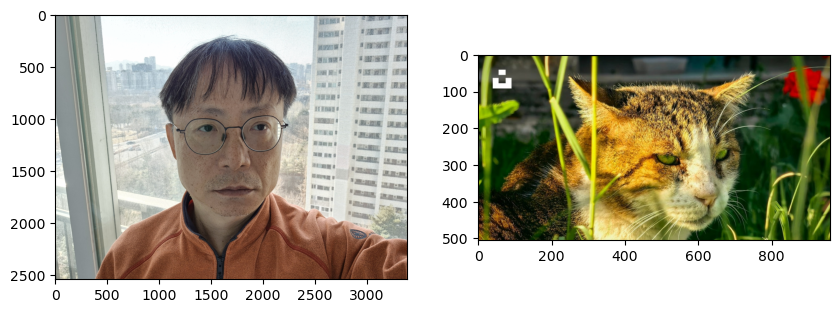

In [31]:
imgag_path = "image2.jpg"
cat_path = "cat2.jpg"

image_img = cv2.imread(imgag_path)
cat_img = cv2.imread(cat_path)

image_rgb = cv2.cvtColor(image_img, cv2.COLOR_BGR2RGB)
cat_rgb = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)

print(f"인물사진 이미지 크기: {image_rgb.shape}")
print(f"고양이 이미지 크기: {cat_rgb.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)

plt.subplot(1, 2, 2)
plt.imshow(cat_rgb)

plt.show()


## 모델 적용 (세그멘테이션)

In [32]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

img_input_tensor = transform(image_rgb).unsqueeze(0)
cat_input_tensor = transform(cat_rgb).unsqueeze(0)


with torch.no_grad():
    img_output = model(img_input_tensor)["out"][0]
    cat_output = model(cat_input_tensor)["out"][0]
    img_output_predictions = img_output.argmax(0).byte().cpu().numpy()
    cat_output_predictions = cat_output.argmax(0).byte().cpu().numpy()

print(f"인물 사진 추론 마스크 크기 (Before Resize): {img_output_predictions.shape}")
print(f"고양이 사진 추론 마스크 크기 (Before Resize): {cat_output_predictions.shape}")


인물 사진 추론 마스크 크기 (Before Resize): (520, 520)
고양이 사진 추론 마스크 크기 (Before Resize): (520, 520)


## 마스크를 원본 크기로

In [34]:
# 마스크를 원본 크기로 Resize
img_output_predictions_resized = cv2.resize(img_output_predictions, (image_img.shape[1], image_img.shape[0]), interpolation=cv2.INTER_NEAREST)
cat_output_predictions_resized = cv2.resize(cat_output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"인물 사진 추론 마스크 크기 (After Resize): {img_output_predictions_resized.shape}")
print(f"고양이 사진 추론 마스크 크기 (After Resize): {cat_output_predictions_resized.shape}")


인물 사진 추론 마스크 크기 (After Resize): (2544, 3392)
고양이 사진 추론 마스크 크기 (After Resize): (504, 960)


## 예측 클래스 ID 확인

In [35]:
img_unique_classes = np.unique(img_output_predictions_resized)
cat_unique_classes = np.unique(cat_output_predictions_resized)
print(f"인물 사진 예측된 클래스 ID: {img_unique_classes}")
print(f"고양이 사진 예측된 클래스 ID: {cat_unique_classes}")


인물 사진 예측된 클래스 ID: [ 0 15]
고양이 사진 예측된 클래스 ID: [0 8]


## 마스크 이미지 확인

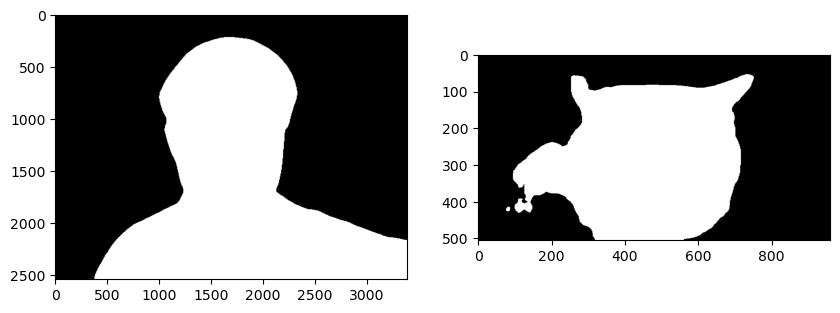

In [36]:
img_target_class_id = img_unique_classes[-1]
cat_target_class_id = cat_unique_classes[-1]

img_seg_map = (img_output_predictions_resized == img_target_class_id)
cat_seg_map = (cat_output_predictions_resized == cat_target_class_id)

img_img_mask = img_seg_map.astype(np.uint8) * 255
cat_img_mask = cat_seg_map.astype(np.uint8) * 255

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_img_mask, cmap='gray')

plt.subplot(1, 2, 2)
plt.imshow(cat_img_mask, cmap='gray')

plt.show()


## 원본이미지 + 마스크 이미지

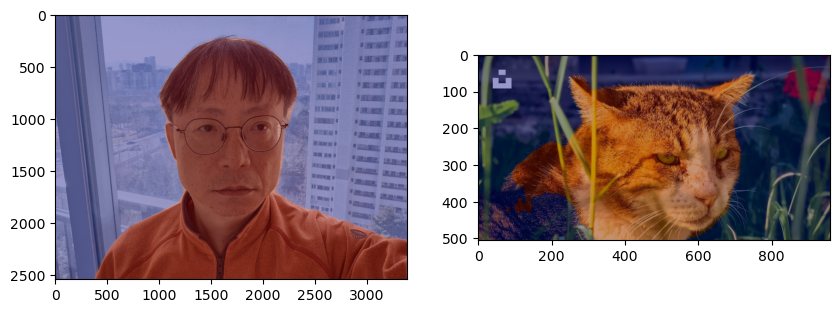

In [38]:
# 원본 이미지와 마스트를 적당히 합쳐봅니다
# 0.6과 0.4는 두 이미지를 섞는 비율입니다.

img_color_mask = cv2.applyColorMap(img_img_mask, cv2.COLORMAP_JET)
cat_color_mask = cv2.applyColorMap(cat_img_mask, cv2.COLORMAP_JET)

img_img_show = cv2.addWeighted(image_img, 0.6, img_color_mask, 0.4, 0.0)
cat_img_show = cv2.addWeighted(cat_img, 0.6, cat_color_mask, 0.4, 0.0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_img_show, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(cat_img_show, cv2.COLOR_BGR2RGB))

plt.show()


## 배경 흐리게 하기

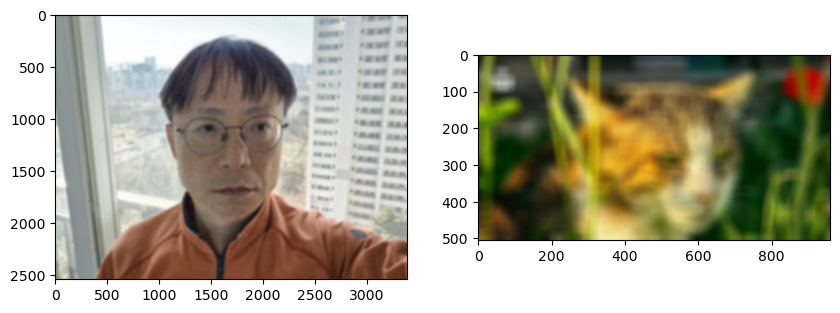

In [40]:
# (13,13)은 blurring kernel size를 뜻합니다
# 다양하게 바꿔보세요
img_img_blur = cv2.blur(image_img, (32, 32))  # 좀더 흐리게
cat_img_blur = cv2.blur(cat_img, (32, 32))  # 좀더 흐리게


# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_img_blur, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(cat_img_blur, cv2.COLOR_BGR2RGB))

plt.show()

### 배경 추출

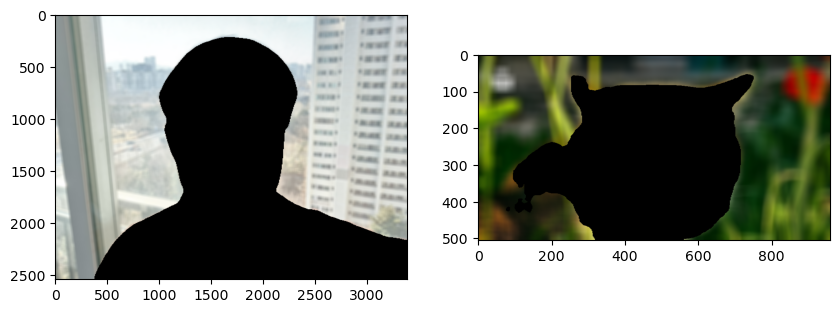

In [41]:
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
img_mask_color = cv2.cvtColor(img_img_mask, cv2.COLOR_GRAY2BGR)
cat_mask_color = cv2.cvtColor(cat_img_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지가 반전됩니다. 배경이 0 사람이 255 였으나
# 연산을 하고 나면 배경은 255 사람은 0입니다.
img_bg_mask = cv2.bitwise_not(img_mask_color)
cat_bg_mask = cv2.bitwise_not(cat_mask_color)

# cv2.bitwise_and()을 사용하면 배경만 있는 영상을 얻을 수 있습니다.
# 0과 어떤 수를 bitwise_and 연산을 해도 0이 되기 때문에
# 사람이 0인 경우에는 사람이 있던 모든 픽셀이 0이 됩니다. 결국 사람이 사라지고 배경만 남아요!
img_bg_blur = cv2.bitwise_and(img_img_blur, img_bg_mask)
cat_bg_blur = cv2.bitwise_and(cat_img_blur, cat_bg_mask)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(cat_bg_blur, cv2.COLOR_BGR2RGB))

plt.show()

## 흐린 배경과 원본 영상 합성

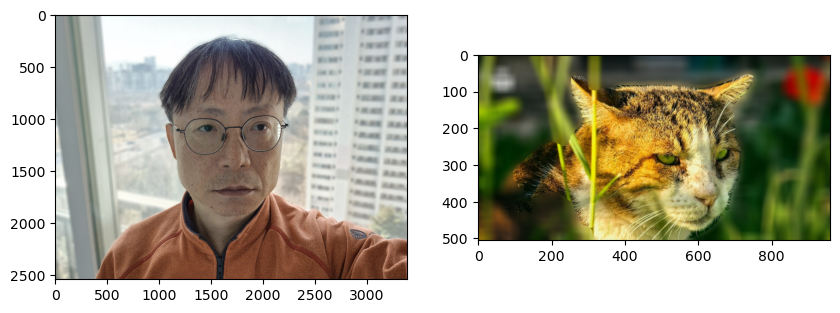

In [43]:
# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고
# 아닌 영역은 블러된 이미지 값을 사용합니다.
img_img_concat = np.where(img_mask_color==255, image_img, img_bg_blur)
cat_img_concat = np.where(cat_mask_color==255, cat_img, cat_bg_blur)


# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_img_concat, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(cat_img_concat, cv2.COLOR_BGR2RGB))

plt.show()